# Premier League 2025/26 market value prediction

In [27]:
import requests
import os
from dotenv import load_dotenv
load_dotenv()
import pandas as pd
from datetime import date

headers = { 'X-Auth-Token': os.getenv('FOOTBALL_DATA_API_TOKEN') }

uri_basic_info = 'https://api.football-data.org/v4/competitions/PL/teams/'
params_season_basic_info = { 'season': '2025'}

uri_scorers = 'https://api.football-data.org/v4/competitions/PL/scorers/'
params_season_and_limit_for_scorers = { 'limit': '652', 'season': '2025'}

uri_team_standings = 'https://api.football-data.org/v4/competitions/PL/standings/'
params_season_standings = {'season': '2025'}

In [28]:
response_basic_info = requests.get(uri_basic_info, headers=headers, params=params_season_basic_info)

response_scorers = requests.get(uri_scorers, headers=headers, params=params_season_and_limit_for_scorers)

response_standings = requests.get(uri_team_standings, headers=headers, params=params_season_standings)

Extracting player info (team, player and position) from api

In [29]:
all_player_Data = []

def calculateAge(birthDate):
    today = date.today()
    age = today.year - birthDate.year - ((today.month, today.day) < (birthDate.month, birthDate.day)) 
    return age

for team in response_basic_info.json()['teams']:
    
    for player in team['squad']:
        player_Dictionary = {}

        player_Dictionary['Team'] = team['name']
        player_Dictionary['Player'] = player['name']
        player_Dictionary['Position'] = player['position']
        
        if player['dateOfBirth'] != None:
            year, month, day = map(int, player['dateOfBirth'].split('-'))
            player_Dictionary['Age'] = calculateAge(date(year, month, day))

        all_player_Data.append(player_Dictionary)

Extracting info relevant to strikers and midfielders from api

In [30]:
all_player_data_scorer = []
for entry in response_scorers.json()['scorers']:
    player_scorer_dictionary = {}

    player_scorer_dictionary['Player'] = entry['player']['name']
    player_scorer_dictionary['Goals'] = entry['goals']
    player_scorer_dictionary['Assists'] = entry['assists']

    all_player_data_scorer.append(player_scorer_dictionary)

Data relevant for goalkeepers and defenders (csv fbref)

In [31]:
goalkeeper_data = pd.read_csv('goalkeeper_stats.csv', skiprows=1, usecols=['Player', 'GA90', 'Save%', 'CS%', 'Save%.1'])
goalkeeper_df = pd.DataFrame(goalkeeper_data)
defender_data = pd.read_csv('stats_relevant_for_defenders.csv', skiprows=1, usecols=['Player', 'TklW', 'Int'])
defender_df = pd.DataFrame(defender_data)

Additonal metrics for strikers/midfielders and target variable market value

In [32]:
market_value_data = pd.read_csv('all_player_profiles.csv', usecols=['player_id', 'name', 'league', 'market_value'],)
market_value_data = market_value_data[market_value_data['league'] == 'Premier League']

additional_striker_midfielder_data = pd.read_csv('all_player_stats.csv', usecols=['player_id', 'minutes_played', 'expected_goals', 'expected_assists', 'rating'])

market_value_df = pd.DataFrame(market_value_data)
market_value_df.rename(columns={'name' : 'Player'}, inplace=True) 

additional_striker_midfielder_df = pd.DataFrame(additional_striker_midfielder_data)

Extracting club standings from api

In [33]:
club_standings = []
for standings in response_standings.json()['standings']:

    for club in standings['table']:
    
        club_standings_dict = {}

        club_standings_dict['Club_Rank'] = 21 - club['position']
        club_standings_dict['Team'] = club['team']['name']
        club_standings_dict['Points'] = club['points']
        club_standings.append(club_standings_dict)
    break

club_standings_df = pd.DataFrame(club_standings)
club_standings_df

,Club_Rank,Team,Points
0,20,Arsenal FC,85
1,19,Manchester City FC,78
2,18,Manchester United FC,71
3,17,Aston Villa FC,65
4,16,Liverpool FC,60
5,15,AFC Bournemouth,57
6,14,Sunderland AFC,54
7,13,Brighton & Hove Albion FC,53
8,12,Brentford FC,53
9,11,Chelsea FC,52


Merge all data (goalkeepers, defenders, midfielder, striker)

In [34]:
df = pd.DataFrame(all_player_Data)
df = pd.merge(df, market_value_df, on='Player', how='left')

striker_midfield_data_df = pd.DataFrame(all_player_data_scorer)
df = pd.merge(df, striker_midfield_data_df, on='Player', how='left')

df = pd.merge(df, additional_striker_midfielder_df, on='player_id', how='left')
df = pd.merge(df, defender_data, on='Player', how='left')
df = pd.merge(df, goalkeeper_df, on='Player', how='left')
df = pd.merge(df, club_standings_df, on='Team', how='left')
df = df.drop(columns=['player_id', 'league'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 674 entries, 0 to 673
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Team              674 non-null    str    
 1   Player            674 non-null    str    
 2   Position          674 non-null    str    
 3   Age               673 non-null    float64
 4   market_value      484 non-null    float64
 5   Goals             275 non-null    float64
 6   Assists           206 non-null    float64
 7   minutes_played    425 non-null    float64
 8   expected_goals    368 non-null    float64
 9   expected_assists  421 non-null    float64
 10  rating            425 non-null    float64
 11  TklW              452 non-null    float64
 12  Int               452 non-null    float64
 13  GA90              33 non-null     float64
 14  Save%             32 non-null     float64
 15  CS%               32 non-null     float64
 16  Save%.1           26 non-null     float64
 17  Club_Ran

## Data Pre Processing

In [35]:
print(f"rows in total: {len(df)}")
print(f"NaN in market_value: {df['market_value'].isna().sum()}")
print(f"NaN in Goals (Scorer-Merge): {df['Goals'].isna().sum()}")

# Stichprobe: welche Spieler aus market_value_df wurden NICHT gematcht?
unmatched = market_value_df[~market_value_df['Player'].isin(df['Player'])]
print(f"unmatched players from market_value_df: {len(unmatched)}")
print(unmatched['Player'].tolist())

rows in total: 674
NaN in market_value: 190
NaN in Goals (Scorer-Merge): 399
unmatched players from market_value_df: 104
['Gabriel Martinelli', "Ceadach O'Neill", 'Martin Odegaard', 'Christian Norgaard', 'Ife Ibrahim', 'Jurriën Timber', 'Alexei Rojas', 'Jérémy Doku', 'Savinho', 'Nico González', 'Rayan Aït-Nouri', 'Ruben Dias', 'Nathan Ake', 'Dermot Mee', 'Brian Madjo', 'Mohamed Kone', 'Victor Lindelof', 'Andrés García', 'Yeimar Mosquera', 'Emiliano Martinez', 'Hugo Ekitiké', 'Wataru Endo', 'Stefan Bajčetić', 'Miloš Kerkez', 'Andy Robertson', 'Alisson', 'Ármin Pécsi', 'Kornel Misciur', 'Deivid Washington', 'Estêvão', 'Mykhaylo Mudryk', 'Jamie Gittens', 'Roméo Lavia', 'Dário Essugo', 'Sam Rak-Sakyi', 'Marc Cucurella', 'Genesis Antwi', 'Filip Jørgensen', 'Gabriel Słonina', 'Igor Thiago', 'Yehor Yarmolyuk', 'Joshua Dasilva', 'Joshua Stephenson', 'Eli Junior Kroupi', 'Enes Unal', 'Michael Dacosta Gonzalez', 'Ben Gannon-Doak', 'Alex Tóth', 'Owen Bevan', 'Harold William', 'Yankuba Minteh', 'I

Because the api didn't have data of market values I was forced to get the market value data from an external source. To be more specific from the database fbref. That resulted in a tally of 104 unmatched players. For the NaN's in the goal metrics it can be explained by saying that throughout the 25/26 Premier League season 399 players didn't score. Furtheremore 190 players had no market value entry due to being very young or being in the set of players that are unmatched. 

In [36]:
from difflib import get_close_matches

df_players = df['Player'].tolist()
recovered = []
still_missing = []

for name in unmatched['Player']:
    match = get_close_matches(name, df_players, n=1, cutoff=0.8)
    if match:
        recovered.append((name, match[0]))
    else:
        still_missing.append(name)

print(f'{len(recovered)} potential spelling mismatch, {len(still_missing)} not in squad')
for orig, matched in recovered:
    print(f'{orig}  ->  {matched}')

61 potential spelling mismatch, 43 not in squad
Ceadach O'Neill  ->  Ceadach O’Neill
Martin Odegaard  ->  Martin Ødegaard
Christian Norgaard  ->  Christian Nørgaard
Ife Ibrahim  ->  Ifeoluwa Ibrahim
Jurriën Timber  ->  Jurrien Timber
Jérémy Doku  ->  Jeremy Doku
Nico González  ->  Nico Gonzalez
Rayan Aït-Nouri  ->  Rayan Aït Nouri
Ruben Dias  ->  Rúben Dias
Nathan Ake  ->  Nathan Aké
Mohamed Kone  ->  Mohamed Koné
Andrés García  ->  Andrés Garcia
Yeimar Mosquera  ->  Yerson Mosquera
Emiliano Martinez  ->  Emiliano Martínez
Hugo Ekitiké  ->  Hugo Ekitike
Wataru Endo  ->  Wataru Endō
Stefan Bajčetić  ->  Stefan Bajcetic
Miloš Kerkez  ->  Milos Kerkez
Andy Robertson  ->  Andrew Robertson
Alisson  ->  Alysson
Ármin Pécsi  ->  Armin Pecsi
Kornel Misciur  ->  Kornel Miściur
Mykhaylo Mudryk  ->  Mykhailo Mudryk
Jamie Gittens  ->  Jamie Bynoe-Gittens
Roméo Lavia  ->  Romeo Lavia
Dário Essugo  ->  Dario Essugo
Filip Jørgensen  ->  Filip Jörgensen
Gabriel Słonina  ->  Gabriel Slonina
Yehor Yarmo

To know why I had various unmatched players I went ahead and checked if that problem occured due to different spellings, misspelling or the player simply not existing in the api or vice versa. After checking, 61 players indeed were spelled differently e.g. Martin Odegaard and Martin Ødegaard or player names were shortened like Ife Ibrahim and Ifeoluwa Ibrahim. 43 players simply were not in the csv or api.

In [37]:
name_fixes = {
    "Ceadach O'Neill": "Ceadach O'Neill",
    "Martin Odegaard": "Martin Ødegaard",
    "Christian Norgaard": "Christian Nørgaard",
    "Ife Ibrahim": "Ifeoluwa Ibrahim",
    "Jurriën Timber": "Jurrien Timber",
    "Jérémy Doku": "Jeremy Doku",
    "Nico González": "Nico Gonzalez",
    "Rayan Aït-Nouri": "Rayan Aït Nouri",
    "Ruben Dias": "Rúben Dias",
    "Nathan Ake": "Nathan Aké",
    "Mohamed Kone": "Mohamed Koné",
    "Andrés García": "Andrés Garcia",
    "Emiliano Martinez": "Emiliano Martínez",
    "Hugo Ekitiké": "Hugo Ekitike",
    "Wataru Endo": "Wataru Endō",
    "Stefan Bajčetić": "Stefan Bajcetic",
    "Miloš Kerkez": "Milos Kerkez",
    "Andy Robertson": "Andrew Robertson",
    "Ármin Pécsi": "Armin Pecsi",
    "Kornel Misciur": "Kornel Miściur",
    "Mykhaylo Mudryk": "Mykhailo Mudryk",
    "Jamie Gittens": "Jamie Bynoe-Gittens",
    "Roméo Lavia": "Romeo Lavia",
    "Dário Essugo": "Dario Essugo",
    "Filip Jørgensen": "Filip Jörgensen",
    "Gabriel Słonina": "Gabriel Slonina",
    "Yehor Yarmolyuk": "Yegor Yarmolyuk",
    "Joshua Dasilva": "Josh Dasilva",
    "Joshua Stephenson": "Josh Stephenson",
    "Enes Unal": "Enes Ünal",
    "Alex Tóth": "Alex Toth",
    "Yankuba Minteh": "Yankubah Minteh",
    "Igor Júlio": "Igor Julio",
    "Joel Veltman": "Joël Veltman",
    "Tom McGill": "Thomas McGill",
    "Idrissa Gana Gueye": "Idrissa Gana Guèye",
    "Kiernan Dewsbury-Hall": "Kiernan Dewsbury Hall",
    "Vitaliy Mykolenko": "Vitalii Mykolenko",
    "Tom King": "Thomas King",
    "Bertrand Traore": "Bertrand Traoré",
    "Raul Jimenez": "Raúl Jiménez",
    "Sasa Lukic": "Saša Lukić",
    "Samuel Amissah": "Sam Amissah",
    "Edward Nketiah": "Eddie Nketiah",
    "Walter Benitez": "Walter Benítez",
    "Fabian Schar": "Fabian Schär",
    "Adama Traore": "Adama Traoré",
    "Mohamadou Kanté": "Mohamadou Kante",
    "Joao Palhinha": "João Palhinha",
    "Cristian Romero": "Christian Romero",
    "Radu Drăguşin": "Radu Drăgușin",
    "Micky van de Ven": "Mickey van de Ven",
    "Florentino Luís": "Florentino",
    "Vaclav Hladky": "Václav Hladký",
    "Tolu Arokodare": "Toluwalas Arokodare",
    "Enso González": "Enso Gonzalez",
    "El Hadji Malick Diouf" : "El Hadji Diouf",
    "Jocelin Ta Bi" : "Jocelin Bi"
    # not in (different players):
    # Alisson / Alysson
    # Yeimar Mosquera / Yerson Mosquera
    # Alfie Harrison / Ollie Harrison
}

market_value_df['Player'] = market_value_df['Player'].replace(name_fixes)

All missing values are of numerical type so they will be filled with 0.0 + players that had positions that are null or unclear are edited (***Only 4 positions***: goalkeeper/defence/midfield/offence)

In [38]:
df = df[df['market_value'].notna()]
df = df.fillna(0)
df.drop_duplicates(inplace=True, ignore_index=True)

def clean_data(df):
    df.loc[df['Player'] == 'Khari Ranson', 'Position'] = 'Goalkeeper'
    df.loc[df['Player'] == 'Jadon Sancho', 'Position'] = 'Offence'
    df.loc[df['Player'] == 'Rhys Williams', 'Position'] = 'Defence'
    df.loc[df['Player'] == 'Jayden Danns', 'Position'] = 'Offence'
    df.loc[df['Player'] == 'James McConnell', 'Position'] = 'Midfield'
    df.loc[df['Player'] == 'Kaide Gordon', 'Position'] = 'Offence'
    df.loc[df['Player'] == 'Tyrell Malacia', 'Position'] = 'Defence'
    df.loc[df['Player'] == 'Emil Krafth', 'Position'] = 'Defence'
    df.loc[df['Player'] == 'Bertrand Traoré', 'Position'] = 'Offence'
    df.loc[df['Player'] == 'Milan Aleksić', 'Position'] = 'Midfield'
    df.loc[df['Player'] == 'Yves Bissouma', 'Position'] = 'Midfield'
    df.loc[df['Player'] == 'Rhys Chadwick', 'Position'] = 'Midfield'
    df.loc[df['Player'] == 'Jayden Lienou', 'Position'] = 'Defence'
    df.loc[df['Player'] == 'Willy Boly', 'Position'] = 'Defence'
    df.loc[df['Player'] == 'Kaden Rodney', 'Position'] = 'Midfield'
    df.loc[df['Player'] == 'James Milner', 'Position'] = 'Midfield'
    df.loc[df['Player'] == 'Adam Webster', 'Position'] = 'Defence'
    df.loc[df['Player'] == 'Solly March', 'Position'] = 'Offence'
    return df

df = clean_data(df)
df.info

<bound method DataFrame.info of                 Team             Player    Position   Age  market_value  \
0         Arsenal FC  Kepa Arrizabalaga  Goalkeeper  31.0     7400000.0   
1         Arsenal FC         David Raya  Goalkeeper  31.0    38000000.0   
2         Arsenal FC      Tommy Setford  Goalkeeper  20.0      930000.0   
3         Arsenal FC          Ben White     Defence  28.0    27000000.0   
4         Arsenal FC  Gabriel Magalhães     Defence  28.0    70000000.0   
..               ...                ...         ...   ...           ...   
477  AFC Bournemouth         Alex Scott    Midfield  23.0    43000000.0   
478  AFC Bournemouth       David Brooks     Offence  29.0    12800000.0   
479  AFC Bournemouth          Evanilson     Offence  26.0    33000000.0   
480  AFC Bournemouth         Amine Adli     Offence  26.0    18100000.0   
481  AFC Bournemouth              Rayan     Offence  20.0    39000000.0   

     Goals  Assists  minutes_played  expected_goals  expected_assis

#### One-Hot-Encode 
ensure that the model values specific metrics according to the position of the player

In [39]:
df_encoded = pd.get_dummies(df, columns=['Position'], drop_first=True)
df_encoded = df_encoded.set_index('Player')
df_encoded = df_encoded.drop(columns=['Team'])
df_encoded

,Age,market_value,Goals,Assists,minutes_played,expected_goals,expected_assists,rating,TklW,Int,GA90,Save%,CS%,Save%.1,Club_Rank,Points,Position_Goalkeeper,Position_Midfield,Position_Offence
Player,,,,,,,,,,,,,,,,,,,
Kepa Arrizabalaga,31.0,7400000.0,0.0,0.0,0.0,0.0000,0.000000,0.000000,0.0,0.0,1.0,66.7,0.0,0.0,20,85,True,False,False
David Raya,31.0,38000000.0,0.0,0.0,2970.0,0.0000,0.105527,6.887879,1.0,1.0,0.7,69.8,51.4,0.0,20,85,True,False,False
Tommy Setford,20.0,930000.0,0.0,0.0,0.0,0.0000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,20,85,True,False,False
Ben White,28.0,27000000.0,0.0,0.0,512.0,0.4567,0.499445,6.811111,9.0,9.0,0.0,0.0,0.0,0.0,20,85,False,False,False
Gabriel Magalhães,28.0,70000000.0,3.0,4.0,2346.0,1.9818,1.749147,7.333333,20.0,22.0,0.0,0.0,0.0,0.0,20,85,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Alex Scott,23.0,43000000.0,3.0,1.0,2500.0,3.7042,2.391769,7.056250,38.0,35.0,0.0,0.0,0.0,0.0,15,57,False,True,False
David Brooks,29.0,12800000.0,1.0,3.0,1109.0,4.9385,3.074704,6.674074,13.0,4.0,0.0,0.0,0.0,0.0,15,57,False,False,True
Evanilson,26.0,33000000.0,6.0,2.0,2384.0,9.3241,1.206746,6.612903,5.0,6.0,0.0,0.0,0.0,0.0,15,57,False,False,True


Dropping goalkeeper metrics and goalkeepers due to analyzation of feature importance later in the file

In [40]:
if 'Position_Goalkeeper' in df_encoded.columns:
  df_encoded = df_encoded[df_encoded['Position_Goalkeeper'] != 1]

goalkeeper_columns_to_drop = ['GA90', 'Save%', 'CS%', 'Save%.1', 'Position_Goalkeeper']
df_encoded = df_encoded.drop(columns=[col for col in goalkeeper_columns_to_drop if col in df_encoded.columns])

Target value: market value

In [41]:
X = df_encoded.drop('market_value', axis=1)
#target feature
y = df_encoded['market_value']

#### Split Data in train, validation and test (60/20/20)

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42,shuffle=True)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, shuffle=True)
print(X_train.shape, X_test.shape)

(255, 13) (85, 13)


#### Standardize numerical values

In [43]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

numerical_columns = X.select_dtypes(include=['float64', 'int64']).columns.to_list()
scaler = ColumnTransformer(transformers=[('scale_continous', StandardScaler(), numerical_columns)], remainder='passthrough')

kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [44]:
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled= scaler.transform(X_test)

## First Baseline (Ridge Regression)

In [45]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import root_mean_squared_error, r2_score


alphas = [0.0001,0.001,0.01,0.1,1.0,5.0,10.0,100.0,1000.0,10000.0]
ridge_cv_model = RidgeCV(alphas=alphas, store_cv_results=True)
ridge_cv_model.fit(X_train_scaled, y_train)

y_pred_ridge_cv = ridge_cv_model.predict(X_test_scaled)
rsme_ridge_cv = root_mean_squared_error(y_test, y_pred=y_pred_ridge_cv)
r2_ridge_cv = r2_score(y_test, y_pred=y_pred_ridge_cv)
print(f"Optimal lambda: {ridge_cv_model.alpha_}")
print(f'RSME score: {rsme_ridge_cv:,.2f}')
print(f'r2 score: {r2_ridge_cv:,.2f}')

Optimal lambda: 100.0
RSME score: 18,400,159.10
r2 score: 0.43


After usage of Ridge Regresion with Cross Validation as first baseline the results are bad. The model fails to predict the market value by approx. 18 million euros which is a big error. If one would compare that to the average market value which is 20-25 million then it becomes obvious that the model is not good enough to predict market values. This evaluation is also clearly backed by an R2 score of 0.43.

## Second Baseline (RandomForest)

In [46]:
from sklearn.ensemble import RandomForestRegressor
estimators = range(50,501,50)

oob_score = 0
best_estimator = 0
for estimator in estimators:
    rf_regressor = RandomForestRegressor(
        n_estimators=estimator,
        random_state=42,
        oob_score=True,
        n_jobs=-1
    )

    rf_regressor.fit(X_train_scaled, y_train)

    if oob_score < rf_regressor.oob_score_:
        oob_score = rf_regressor.oob_score_
        best_estimator = estimator

print(f'Trees {best_estimator} and oob-score {oob_score:,.2f}')

Trees 300 and oob-score 0.50


Before making use of the Random Forest Regressor, I wanted to know what the optimal estimator is to be precise the optimal number of trees which the model is going to examine. The model has the highest out of bag score (0.50), which means the training will be most accurate when using 300 trees. Thus the model will be trained using 300 trees.

In [47]:
rf_regressor = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    oob_score=True,
    n_jobs=-1
)

rf_regressor.fit(X_train_scaled, y_train)

y_pred_rf = rf_regressor.predict(X_test_scaled)

rsme_rf = root_mean_squared_error(y_test, y_pred=y_pred_rf)
print(f'RSME score: {rsme_rf:,.2f}')
r2_rf = r2_score(y_test, y_pred=y_pred_rf)
print(f'R2 score: {r2_rf:,.2f}')

RSME score: 16,637,063.24
R2 score: 0.53


The Random Forest Regressor fails to predict the market value by almost 17 million euroes, which is still not good enough to be considered a good prediction. In addition to that it has a R2 score of 0.54.

Feature importance with goalkeepers

|     | Feature | Gini Importance |
| --- | ---     | --- |
|   4 | expected_goals | 0.331453 |
|   5 | expected_assists | 0.116152 |
|   1 | Goals | 0.106521 |
|   6 | rating | 0.087225 |
|   0 | Age | 0.084387 |
|   13 | Club_Rank | 0.071277 |
|   14 | Points | 0.061667 |
|   3 | minutes_played | 0.059914 |
|   2 | Assists | 0.034294 |
|   7 | TklW | 0.024011 |
|   8 | Int | 0.012111 |
|   16 | Position_Midfield | 0.005653 |
|   17 | Position_Pffence | 0.002506 |
|   11 | CS% | 0.001383 |
|   10 | Save% | 0.000725 |
|   9 | GA90 | 0.000383 |
|   15 | Position_Goalkeeper | 0.000318 |
|   12 | Save%.1 | 0.000020 |

By viewing the feature importance (measured via the Gini-Importance) of the random forest model it can be analyzed which metrics impacts the model the most. Suprisingly, expected goals and assist got the highest Gini-Importance of all metrics by a significant margin, I thought goals and assist would dominate but my hypothesis was wrong. I would explain this result by saying that it says alot more about a player how much goals could be scored or assisted than the actual goal and assist tally, however one could make the argument that a high xgoals value in relation to low goal tally actually tells us that the striker is a bad finisher so that should be included in the prediction of the market value.

Metrics that I expected to be of high importance like age, rating, minutes played are reflected by the random forest.

Furtheremore the Gini importance table clearly reveals an offensive bias due to the fact that the metrics of most importance are the ones that are of most value in judging how good an attacker or midfielder is. Therefore metrics that are of importance to goalkeepers (Save%, Save%.1 (penalty save percentage), CS%) have little to no significance to this model, which is why I will be dropping the goalkeeper metrics. It would've made more sense to have a different dataset only for goalkeepers. 

Feature importance after excluding goalkeepers

In [48]:
importances = rf_regressor.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': X_train.columns, 'Gini Importance': importances}).sort_values(
    'Gini Importance', ascending=False)
print(feature_imp_df)

              Feature  Gini Importance
4      expected_goals         0.217804
3      minutes_played         0.116736
1               Goals         0.105333
9           Club_Rank         0.096919
5    expected_assists         0.095769
10             Points         0.094951
6              rating         0.087053
0                 Age         0.070295
2             Assists         0.044628
8                 Int         0.033203
7                TklW         0.028776
11  Position_Midfield         0.005380
12   Position_Offence         0.003154


After discarding goalkeeper metrics there are some noticable changes in importance regarding the features of the dataset. Expected Goals remains the most important feature but ecpected assists plumits to fifth most important feature after being second most important before removing data relevant to goalkeepers. In addition to that the club rank and the minutes played by each individual player now has a high gini importance, which benefits all players not just Fowards, because the feature importance shows that the model gives most importance to metrics benefitting strikers the most.

## Final model (LightGBM)

In [49]:
import lightgbm as lgb
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,        
    num_leaves=25,             
    max_depth=-1,              
    min_child_samples=10,      
    subsample=0.9,             
    colsample_bytree=0.9,      
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(
    X_train_scaled, y_train, 
    eval_set=[(X_val_scaled, y_val)], 
    eval_metric='rmse',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)

y_pred_lgb = lgbm_model.predict(X_test_scaled)

rmse_lgb = root_mean_squared_error(y_test, y_pred_lgb)
r2_lgb = r2_score(y_test, y_pred_lgb)

print(f"LightGBM RMSE: {rmse_lgb:,.2f} €")
print(f"LightGBM R2 Score: {r2_lgb:.4f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,000277 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 464
[LightGBM] [Info] Number of data points in the train set: 255, number of used features: 13
[LightGBM] [Info] Start training from score 24927411,756863
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

c:\Users\demyi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


LightGBM has a RMSE of 15.5 million that means on average the model fails to predict the correct market value by 15.5 million and also has a R2 score of 0.6, which means the model fails to determine 40% of the remaining variance from the target metric.

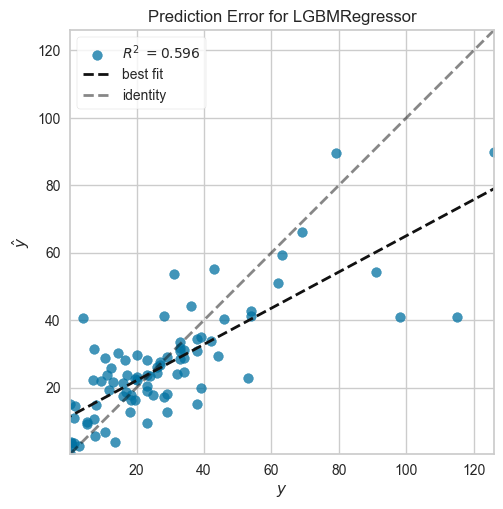

<Axes: title={'center': 'Prediction Error for LGBMRegressor'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [50]:
from yellowbrick.regressor import PredictionError
import matplotlib.ticker as ticker

visualizer = PredictionError(lgbm_model, is_fitted=True, force_model=True)
visualizer.score(X_test_scaled, y_test)

ax = visualizer.ax
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{y/1e6:.0f}'))
visualizer.show()

This plot shows how the market value prediction differs from the actual market value. The x-axis represents the actual market value, while the y-axis reprents the predictions made by the model. Therefore the points marked in blue are players in the dataset. The identy line shows how the line would look if our model predicted perfectly on the other hand the best fit line characterizes how the model actually predicted. The plot indicates that the model predicts lower market values with higher acurracy than high market values, which can be seen by the intersection at (23/23) where both lines cross. Market values till the 40 million bound are predicted adequately with few outliers, but after the 40 million mark that is when it can be seen that best fit and identity line increase in seperation with higher market values, due to prediction and actual value being high off mark.

### Model comparison

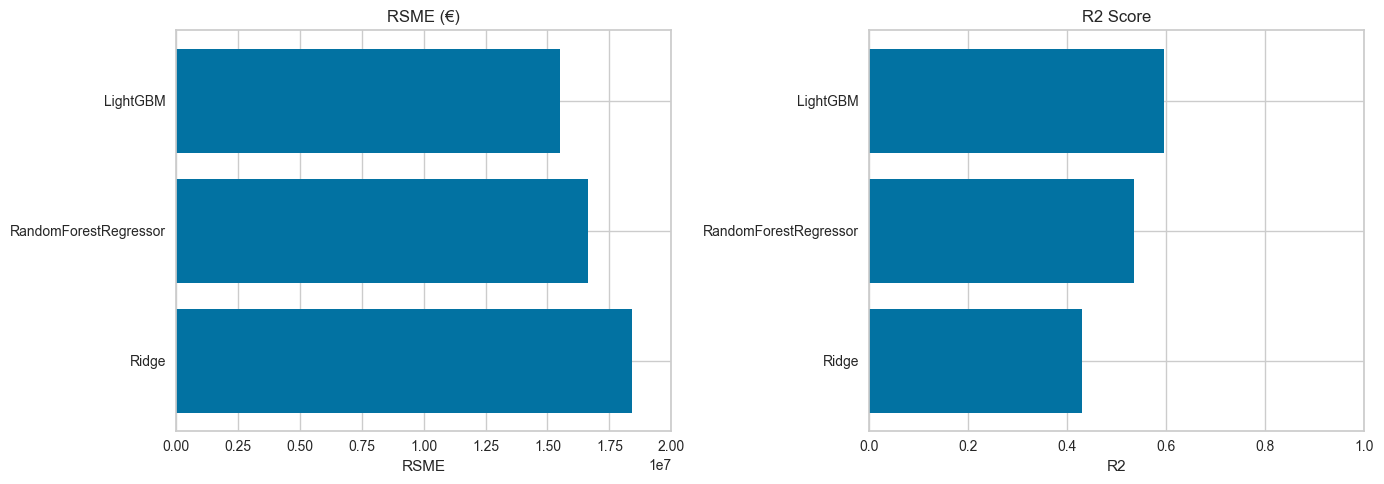

In [51]:
import matplotlib.pyplot as plt
import numpy as np
models = ['Ridge', 'RandomForestRegressor', 'LightGBM',]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
rsme_values = [rsme_ridge_cv, rsme_rf, rmse_lgb]
r2_values = [r2_ridge_cv, r2_rf, r2_lgb]

ax1.barh(models, rsme_values)
ax1.set_title('RSME (€)')
ax1.set_xlabel('RSME')
ax1.set_xlim(0, 20000000)

ax2.barh(models,r2_values)
ax2.set_title('R2 Score')
ax2.set_xlabel('R2')
ax2.set_xlim(0,1)

plt.tight_layout()
plt.show()


It can be seen that with higher complexity models the rsme and the r2 improve though the overall result is not satisfying enough, due to for this context high rsme scores and low r2 values. The best model is LightGBM, which beats the Random Forest Regressor by 1 million and the Ridge Regression by 3 million.

In [52]:
residuals = y_test - y_pred_lgb

results_df = pd.DataFrame({
    'Player': X_test.index,
    'Actual': y_test.values,
    'Predicted': y_pred_lgb,
    'Residual': residuals.values
})
results_df['Abs_Residual'] = results_df['Residual'].abs()

results_df.sort_values('Abs_Residual', ascending=False).head(10).round(1)

,Player,Actual,Predicted,Residual,Abs_Residual
81,Moisés Caicedo,115000000.0,40975126.5,74024873.5,74024873.5
13,Ryan Gravenberch,98000000.0,41047306.0,56952694.0,56952694.0
84,Dominik Szoboszlai,91000000.0,54124946.5,36875053.5,36875053.5
74,Danny Welbeck,4200000.0,40624418.6,-36424418.6,36424418.6
15,Bukayo Saka,126000000.0,90016875.6,35983124.4,35983124.4
62,Carlos Baleba,53000000.0,22714252.1,30285747.9,30285747.9
50,Casemiro,7300000.0,31385044.0,-24085044.0,24085044.0
6,Dominic Solanke,38000000.0,15215809.5,22784190.5,22784190.5
23,Mikel Merino,31000000.0,53632730.1,-22632730.1,22632730.1
14,Valentino Livramento,39000000.0,19865546.3,19134453.7,19134453.7


This is insight on the players market values that the model falsely predicted by a huge margin. As a person that watches a lot of football I can say that players on this list either overperformed, played well/poorly but that didn't translate to the metrics used or the market value is based on the prestige/reputation of the player which also can't be translated to stats. 

Danny Welbeck for example is an overperformer, the prediction valued him higher than his actual value, due to his incredible season with Brighton he had a double digit goal tally and played many minutes. These metrics are most significant to the model, which explains why Danny Welbeck predicted market value is 36 million higher than his actual market value.

Moisés Caicedo on the other hand is a player that had a poor season with his club Chelsea but he has a high actual market value of over 100 million that can be justified by good reputation and good perfomances in past seasons. I would actually agree with the prediction of the model, which predicted Moisés Caicedo to be a 40 million player.

In conclusion to predict market values one needs to have more and precise metrics to determine a justifiable market value, also of importance is the actual eye-test which can't be translated to statistics. The eye-test judges players through the human eyes. A player could perform brilliantly but that player doesn't have the stats to back up his exceptional performances. Therefore I think statistics and eye-test in combination need to be evaluated before concluding on players market value.